In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/mmflood_tiled_hydro.zip -d /content/
!ls /content/mmflood_tiled_hydro/

test  train  val


In [ ]:
import shutil
import os

with open('/content/drive/MyDrive/activations_europe_only.json') as f:
    act_new = json.load(f)

with open('/content/drive/MyDrive/activations.json') as f:
    act_old = json.load(f)

MODALITIES = ['sar', 'dem', 'mask', 'hydro']  #'hydro'

moved = 0
for emsr_id, info_new in act_new.items():
    info_old = act_old.get(emsr_id, {})
    old_subset = info_old.get('subset')
    new_subset = info_new.get('subset')

    if old_subset == new_subset:
        continue

    for modality in MODALITIES:
        src_dir = TILED_ROOT / old_subset / modality
        dst_dir = TILED_ROOT / new_subset / modality
        os.makedirs(dst_dir, exist_ok=True)

        for tile in src_dir.glob(f'{emsr_id}-*.tif'):
            shutil.move(str(tile), str(dst_dir / tile.name))
            moved += 1


for subset in ['train', 'val', 'test']:
    n = len(list((TILED_ROOT / subset / 'sar').glob('*.tif')))
    print(f'{subset}: {n} SAR-Tiles')

2556 Tiles verschoben
train: 2683 SAR-Tiles
val: 323 SAR-Tiles
test: 895 SAR-Tiles


In [ ]:
!pip -q install lightning segmentation-models-pytorch==0.3.3 rasterio albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 73.2 MB/s eta 0:00:00


In [ ]:
import os, json, math
from pathlib import Path
from glob import glob
from tqdm.auto import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import rasterio
import albumentations as alb
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from torchmetrics.classification import BinaryAveragePrecision

torch.set_float32_matmul_precision('high')
L.seed_everything(1337, workers=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

INFO: Seed set to 1337
INFO:lightning.fabric.utilities.seed:Seed set to 1337


Device: cuda


## Config

In [ ]:

train_sar   = len(glob('/content/mmflood_tiled_hydro/train/sar/*.tif'))
train_hydro = len(glob('/content/mmflood_tiled_hydro/train/hydro/*.tif'))
print(f"SAR:   {train_sar}")
print(f"Hydro: {train_hydro}")

SAR:   3276
Hydro: 3276


In [ ]:
TILED_ROOT = Path('/content/mmflood_tiled_hydro')
CKPT_DIR   = '/content/drive/MyDrive/mmflood_ckpt_unet_hydro_mit_europe'
os.makedirs(CKPT_DIR, exist_ok=True)
# Modalities
INCLUDE_DEM = True
USE_HYDRO   = True

MODEL_ARCH      = 'unet' #'deeplabv3+'
ENCODER_NAME    = 'mit_b2' #'resnet50'
ENCODER_WEIGHTS = 'imagenet' #'None'

BATCH_SIZE   = 8
NUM_WORKERS  = 6
MAX_EPOCHS   = 50
LR_START     = 1e-3
LR_END       = 1e-4
POLY_POWER   = 3.0
WEIGHT_DECAY = 0.01
PATIENCE     = 10
EWS_SMOOTHING = 0.8

REPORT_THR = 0.5

_FULL_MEAN = (4.9329374e-02, 1.1776519e-02, 1.4241237e+02, 0.0)
_FULL_STD  = (3.91287043e-02, 1.03687926e-02, 8.11010422e+01, 1.0)
N_CH = 2 + int(INCLUDE_DEM) + int(USE_HYDRO)
MEAN = _FULL_MEAN[:N_CH]
STD  = _FULL_STD[:N_CH]

print(f'Config: {MODEL_ARCH}/{ENCODER_NAME}, DEM={INCLUDE_DEM}, epochs={MAX_EPOCHS}, bs={BATCH_SIZE}')
print(f'Channels: {N_CH}, mean={MEAN}, std={STD}')

Config: unet/mit_b2, DEM=True, epochs=50, bs=8
Channels: 4, mean=(0.049329374, 0.011776519, 142.41237, 0.0), std=(0.0391287043, 0.0103687926, 81.1010422, 1.0)


In [ ]:
for subset in ['train', 'val', 'test']:
    sar  = len(glob(str(TILED_ROOT / subset / 'sar' / '*.tif')))
    dem  = len(glob(str(TILED_ROOT / subset / 'dem' / '*.tif')))
    mask = len(glob(str(TILED_ROOT / subset / 'mask' / '*.tif')))
    print(f'{subset}: SAR={sar}, DEM={dem}, Mask={mask}')

train: SAR=3276, DEM=3276, Mask=3276
val: SAR=369, DEM=369, Mask=369
test: SAR=256, DEM=256, Mask=256


## Augmentierungen (aus prepare.py)

In [ ]:
F32_EPS = np.finfo(np.float32).eps

def get_base_transforms(image_size=512):
    min_crop = image_size // 2
    return alb.Compose([
        alb.RandomSizedCrop(min_max_height=(min_crop, image_size),
                            size=(image_size, image_size), p=0.8),
        alb.HorizontalFlip(p=0.5),
        alb.VerticalFlip(p=0.5),
        alb.RandomRotate90(p=0.5),
        alb.ElasticTransform(alpha=1, sigma=50, p=0.5),
        alb.GridDistortion(p=0.5),
    ])

def get_sar_transforms():
    return alb.Compose([
        alb.OneOf([
            alb.GaussianBlur(blur_limit=(3, 13), p=0.5),
            alb.MultiplicativeNoise(multiplier=(0.7, 1.3),
                                    elementwise=True, per_channel=True, p=0.5),
        ], p=0.6),
    ])

class ClipNormalize(alb.ImageOnlyTransform):
    def __init__(self, mean, std, clip_min=-30.0, clip_max=30.0, p=1.0):
        super().__init__(p=p)
        self.mean     = np.array(mean, dtype=np.float32)
        self.std      = np.array(std,  dtype=np.float32)
        self.clip_min = clip_min
        self.clip_max = clip_max

    def apply(self, img, **params):
        img    = img.astype(np.float32)
        mean   = self.mean[:img.shape[-1]]
        std    = self.std[:img.shape[-1]]
        result = (img - mean) / (std + 1e-7)
        return np.clip(result, self.clip_min, self.clip_max)

    def get_transform_init_args_names(self):
        return ('mean', 'std', 'clip_min', 'clip_max')

def get_eval_transforms(mean, std):
    return alb.Compose([
        ClipNormalize(mean=mean, std=std, clip_min=-30.0, clip_max=30.0),
        ToTensorV2(),
    ])

In [ ]:
def imread(path, channels_first=True):
    with rasterio.open(str(path), mode='r', driver='GTiff') as src:
        image = src.read()
    return image if channels_first else image.transpose(1, 2, 0)

def entropy(label: np.ndarray, ignore: int = 255) -> float:
    valid = label.copy()
    valid[valid == ignore] = 0
    marg = np.histogramdd(valid.ravel(), bins=2)[0] / label.size
    marg = list(filter(lambda p: p > 0, np.ravel(marg)))
    return -np.sum(np.multiply(marg, np.log2(marg)))


class TiledFloodDataset(Dataset):

    def __init__(self, tiled_root, subset, include_dem=True, use_hydro=USE_HYDRO,
                 is_train=False, mean=None, std=None):
        self.include_dem = include_dem
        self.is_train    = is_train
        self.use_hydro   = use_hydro

        root = Path(tiled_root) / subset

        self.sar_files  = sorted(glob(str(root / 'sar'  / '*.tif')))
        self.mask_files = sorted(glob(str(root / 'mask' / '*.tif')))
        if include_dem:
            self.dem_files = sorted(glob(str(root / 'dem' / '*.tif')))
        else:
            self.dem_files = []
        if use_hydro:
            self.hydro_files = sorted(glob(str(root / 'hydro' / '*.tif')))
            assert len(self.sar_files) == len(self.hydro_files), 'SAR/Hydro Mismatch'
        else:
            self.hydro_files = []

        assert len(self.sar_files) > 0, f'Keine Tiles in {root}/sar'
        assert len(self.sar_files) == len(self.mask_files), 'SAR/Mask Mismatch'
        if include_dem:
            assert len(self.sar_files) == len(self.dem_files), 'SAR/DEM Mismatch'
        self.base_trf = get_base_transforms(512) if is_train else None
        self.sar_trf  = get_sar_transforms()     if is_train else None
        self.norm_trf = get_eval_transforms(mean=mean, std=std)
        self.label_files = self.mask_files

        print(f'  {subset}: {len(self.sar_files)} Tiles')

    def __len__(self):
        return len(self.sar_files)

    def __getitem__(self, idx):
        sar = imread(self.sar_files[idx]).astype(np.float32)
        sar = np.nan_to_num(sar, nan=0.0)

        mask = imread(self.mask_files[idx])[0].astype(np.uint8)
        y01  = mask.astype(np.int64)
        y01[(y01 != 0) & (y01 != 255)] = 1

        sar_hwc = sar.transpose(1, 2, 0)
        if self.sar_trf is not None:
            result  = self.sar_trf(image=sar_hwc, mask=y01.astype(np.float32))
            sar_hwc = result['image']
            y01     = result['mask'].astype(np.int64)

        if self.include_dem:
            dem = imread(self.dem_files[idx]).astype(np.float32)[0]
            dem = np.nan_to_num(dem, nan=0.0)
            full_hwc = np.dstack((sar_hwc, dem[:, :, np.newaxis]))
        else:
            full_hwc = sar_hwc
        if self.use_hydro and self.hydro_files:
          hyd = imread(self.hydro_files[idx]).astype(np.float32)[0]
          hyd = np.nan_to_num(hyd, nan=0.0)
          full_hwc = np.dstack((full_hwc, hyd[:, :, np.newaxis]))
        if self.base_trf is not None:
            result   = self.base_trf(image=full_hwc, mask=y01.astype(np.float32))
            full_hwc = result['image']
            y01      = result['mask'].astype(np.int64)

        result = self.norm_trf(image=full_hwc.astype(np.float32),
                               mask=y01.astype(np.float32))
        x_t = result['image'].float()
        x_t = torch.nan_to_num(x_t, nan=0.0)
        y_t = result['mask'].long()

        name = Path(self.sar_files[idx]).stem
        return x_t, y_t, name.split('_')[0], name

## DataModule mit EWS

In [ ]:
def compute_entropy_weights(label_files, smoothing=0.8):
    assert 0 <= smoothing <= 1
    minval = 1.0 - smoothing
    entropies = []
    for path in tqdm(label_files, desc='EWS'):
        label = imread(path)[0]
        entropies.append(entropy(label))
    entropies = np.array(entropies)
    return np.clip(entropies * smoothing + minval, 0, 1)


def mmflood_collate(batch):
    xs, ys, ids, names = zip(*batch)
    return (
        torch.stack([x.clone().contiguous() for x in xs]),
        torch.stack([y.clone().contiguous() for y in ys]),
        list(ids), list(names),
    )


class MMFloodDataModule(L.LightningDataModule):

    def __init__(self, tiled_root, batch_size=42, num_workers=10,
                 include_dem=True, ews_smoothing=0.8, mean=None, std=None, use_hydro=USE_HYDRO):
        super().__init__()
        self.tiled_root   = tiled_root
        self.batch_size   = batch_size
        self.num_workers  = num_workers
        self.include_dem  = include_dem
        self.ews_smoothing= ews_smoothing
        self.mean         = mean
        self.std          = std
        self.use_hydro    = use_hydro

    def setup(self, stage=None):
        kw = dict(include_dem=self.include_dem, mean=self.mean, std=self.std, use_hydro=self.use_hydro)
        self.train_ds = TiledFloodDataset(self.tiled_root, 'train',
                                          is_train=True, **kw)
        self.val_ds   = TiledFloodDataset(self.tiled_root, 'val',
                                          is_train=False, **kw)
        self.test_ds  = TiledFloodDataset(self.tiled_root, 'test',
                                          is_train=False, **kw)

        weights     = compute_entropy_weights(self.train_ds.label_files,
                                              smoothing=self.ews_smoothing)
        num_samples = len(self.train_ds) * 2
        self._sampler = WeightedRandomSampler(
            weights=torch.from_numpy(weights).double(),
            num_samples=num_samples,
            replacement=True,
        )


    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, sampler=self._sampler, num_workers=self.num_workers,pin_memory=True, collate_fn=mmflood_collate, drop_last=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False,num_workers=self.num_workers, pin_memory=True,collate_fn=mmflood_collate)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=1, shuffle=False, num_workers=self.num_workers, pin_memory=True,collate_fn=mmflood_collate)

## Loss: Weighted BCE

In [ ]:
def weighted_bce_loss(logits, y, ignore=255):

    valid = (y != ignore)
    if valid.sum() == 0:
        return logits.sum() * 0.0
    y_valid    = y[valid]
    n_neg      = (y_valid == 0).sum().float()
    n_pos      = (y_valid == 1).sum().float()
    pos_weight = torch.clamp(n_neg / (n_pos + 1), min=1.0, max=50.0)
    return F.binary_cross_entropy_with_logits(
        logits[valid],
        (y_valid == 1).float(),
        pos_weight=pos_weight.to(logits.device),
    )


def micro_stats(logits, y, thr=0.5, ignore=255):
    pred  = torch.sigmoid(logits) > thr
    valid = (y != ignore)
    y01   = (y == 1)
    tp = ( pred &  y01 & valid).sum()
    fp = ( pred & ~y01 & valid).sum()
    fn = (~pred &  y01 & valid).sum()
    return tp, fp, fn


## LightningModule

In [ ]:
class FloodTask(L.LightningModule):

    def __init__(self, in_channels=3, lr_start=1e-3, lr_end=1e-4,
                 poly_power=3.0, weight_decay=0.01, report_thr=0.5,
                 max_epochs=100, model_arch='unet',
                 encoder_name='resnet50', encoder_weights=None):
        super().__init__()
        self.save_hyperparameters()
        self.input_proj = nn.Conv2d(in_channels, 3, kernel_size=1, bias=False) \
                          if in_channels != 3 else nn.Identity()
        self.val_ap  = BinaryAveragePrecision()
        self.test_ap = BinaryAveragePrecision()
        self._reset_accum('val')
        self._reset_accum('test')

        arch = str(model_arch).lower()
        kw   = dict(encoder_name=encoder_name,
                    encoder_weights=encoder_weights,
                    in_channels=3, classes=1)
        if arch in ['deeplabv3+', 'deeplabv3plus']:
            self.model = smp.DeepLabV3Plus(**kw)
        elif arch in ['unet', 'u-net']:
            self.model = smp.Unet(**kw)

    def _reset_accum(self, stage):
        for k in ['tp', 'fp', 'fn', 'valid_total']:
            setattr(self, f'_{stage}_{k}', torch.tensor(0, dtype=torch.long))
    def forward(self, x):
        x = self.input_proj(x)
        return self.model(x).squeeze(1)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr_start,
            weight_decay=self.hparams.weight_decay
        )
        def poly_lr(epoch):
            T    = self.hparams.max_epochs
            g    = self.hparams.poly_power
            lr_s = self.hparams.lr_start
            lr_e = self.hparams.lr_end
            return (lr_e + (lr_s - lr_e) * (1 - epoch / T) ** g) / lr_s
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=poly_lr)
        return [opt], [{'scheduler': sched, 'interval': 'epoch'}]

    def training_step(self, batch, _):
        self.model.train()
        x, y, *_ = batch
        logits    = self(x)
        loss      = weighted_bce_loss(logits, y)
        if not torch.isfinite(loss):
            return logits.sum() * 0.0
        self.log('train/loss', loss, prog_bar=True, on_epoch=True,
                 on_step=False, batch_size=x.shape[0])
        return loss

    def _eval_step(self, batch, stage):
        x, y, *_ = batch
        logits    = self(x)
        loss      = weighted_bce_loss(logits, y)
        if not torch.isfinite(loss):
            return
        self.log(f'{stage}/loss', loss, prog_bar=True, on_epoch=True,
                 on_step=False, batch_size=x.shape[0])

        tp, fp, fn = micro_stats(logits, y, thr=self.hparams.report_thr)
        getattr(self, f'_{stage}_tp').add_(tp.cpu())
        getattr(self, f'_{stage}_fp').add_(fp.cpu())
        getattr(self, f'_{stage}_fn').add_(fn.cpu())

        valid = (y != 255)
        getattr(self, f'_{stage}_valid_total').add_(valid.sum().cpu())
        y01   = (y == 1)
        with torch.no_grad():
            p_flat = torch.sigmoid(logits[valid]).detach().float()
            y_flat = y01[valid].detach().int()
            getattr(self, f'{stage}_ap').update(p_flat, y_flat)

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            vm    = valid.float()
            p_    = probs * vm
            t_    = y01.float() * vm
            inter = (p_ * t_).sum(dim=(1, 2))
            denom = p_.sum(dim=(1, 2)) + t_.sum(dim=(1, 2)) + 1e-7
            dice_soft = ((2 * inter + 1e-7) / denom).mean()
        self.log(f'{stage}/dice_soft', dice_soft, prog_bar=True,
                 on_epoch=True, on_step=False, batch_size=x.shape[0])

    def validation_step(self, batch, _): self._eval_step(batch, 'val')
    def test_step(self, batch, _):
        x, y, *_ = batch
        B, C, H, W = x.shape
        pad_h = (32 - H % 32) % 32
        pad_w = (32 - W % 32) % 32
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), value=0)
            y = F.pad(y, (0, pad_w, 0, pad_h), value=255)
        self._eval_step((x, y), 'test')

    def _log_epoch_metrics(self, stage):
        tp   = getattr(self, f'_{stage}_tp').float()
        fp   = getattr(self, f'_{stage}_fp').float()
        fn   = getattr(self, f'_{stage}_fn').float()
        iou  = tp / (tp + fp + fn + F32_EPS)
        prec = tp / (tp + fp + F32_EPS)
        rec  = tp / (tp + fn + F32_EPS)
        f1   = 2 * prec * rec / (prec + rec + F32_EPS)
        try:
            ap = getattr(self, f'{stage}_ap').compute()
        except Exception:
            ap = torch.tensor(0.0)
        iou_flood = tp / (tp + fp + fn + F32_EPS)


        valid_total = getattr(self, f'_{stage}_valid_total').float()
        tn = valid_total - tp - fp - fn
        iou_bg = tn / (tn + fn + fp + F32_EPS)

        miou = (iou_flood + iou_bg) / 2
        self.log(f'{stage}/iou',  iou,  prog_bar=True)
        self.log(f'{stage}/prec', prec)
        self.log(f'{stage}/rec',  rec)
        self.log(f'{stage}/f1',   f1)
        self.log(f'{stage}/AP',   ap)
        self.log(f'{stage}/miou', miou)
        print(f'[{stage.upper()}] IoU={iou:.4f}  Prec={prec:.4f}  '
              f'Rec={rec:.4f}  F1={f1:.4f}  AP={ap:.4f}')

        self._reset_accum(stage)
        getattr(self, f'{stage}_ap').reset()

    def on_validation_epoch_end(self): self._log_epoch_metrics('val')
    def on_test_epoch_end(self):       self._log_epoch_metrics('test')

## Setup

In [ ]:
dm = MMFloodDataModule(
    tiled_root=TILED_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    include_dem=INCLUDE_DEM,
    use_hydro=USE_HYDRO,
    ews_smoothing=EWS_SMOOTHING,
    mean=MEAN,
    std=STD,
)
dm.setup()

  train: 2683 Tiles
  val: 323 Tiles
  test: 895 Tiles


EWS:   0%|          | 0/2683 [00:00<?, ?it/s]

Train: 2683 | Val: 323 | Test: 895
EWS: 5366 Samples/Epoche


train

In [ ]:
model = FloodTask(
    in_channels=N_CH,
    lr_start=LR_START, lr_end=LR_END,
    poly_power=POLY_POWER, weight_decay=WEIGHT_DECAY,
    report_thr=REPORT_THR, max_epochs=MAX_EPOCHS,
    model_arch=MODEL_ARCH, encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
)

callbacks = [
    ModelCheckpoint(
        dirpath=CKPT_DIR,
        monitor='val/iou', mode='max', save_top_k=1,
        filename='best-{epoch:03d}-iou{val/iou:.4f}',
        verbose=True,
    ),
    EarlyStopping(
        monitor='val/iou', mode='max',
        patience=PATIENCE, verbose=True,
    ),
    LearningRateMonitor(logging_interval='epoch'),
]

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu' if device == 'cuda' else 'cpu',
    devices=1,
    precision='32-true',
    callbacks=callbacks,
    log_every_n_steps=20,
    gradient_clip_val=1.0,
    gradient_clip_algorithm='norm',
    check_val_every_n_epoch=2,
    enable_progress_bar=True,
)

trainer.fit(model, dm, ckpt_path="/content/drive/MyDrive/mmflood_ckpt_unet_hydro_mit_europe/best-epoch=005-iouval/iou=0.3182.ckpt")


eval

In [ ]:
#best_ckpt = trainer.checkpoint_callback.best_model_path
#print(f'Best checkpoint: {best_ckpt}')
best_ckpt = "/content/drive/MyDrive/mmflood_ckpt_unet_hydro_mit_europe/best-epoch=045-iouval/iou=0.3500.ckpt"
from torch.utils.data import DataLoader
test_loader = DataLoader(
    dm.test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=mmflood_collate
)

trainer2 = L.Trainer(
    accelerator='gpu' if device == 'cuda' else 'cpu',
    devices=1,
    precision='16-mixed',
    enable_progress_bar=True,
)

best_model = FloodTask.load_from_checkpoint(best_ckpt,report_thr=0.7)
best_model.to(device)
trainer2.test(best_model, dataloaders=test_loader)

hier aber die iou als (iouwater +iouland) /2 dann bin ich glaub ich schon relativ nah

## Threshold-Sweep auf Val-Set

In [ ]:
best_ckpt = "/content/drive/MyDrive/mmflood_ckpt_unet_hydro_mit_europe/best-epoch=045-iouval/iou=0.3500.ckpt"
@torch.no_grad()
def cache_probs(model, loader, device):
    model.eval()
    probs_all, y_all = [], []
    for x, y, *_ in loader:
        logits = model(x.to(device))
        probs  = torch.sigmoid(logits).cpu()
        valid  = (y != 255)
        probs_all.append(probs[valid])
        y_all.append((y == 1)[valid])
    return torch.cat(probs_all), torch.cat(y_all).bool()

best_model = FloodTask.load_from_checkpoint(best_ckpt)
best_model.to(device).eval()

probs, y_val = cache_probs(best_model, dm.val_dataloader(), device)
print(f'probs: min={probs.min():.3f}  mean={probs.mean():.3f}  max={probs.max():.3f}')

print(f'\n{"Thr":>5}  {"IoU":>7}  {"F1":>7}  {"Prec":>7}  {"Rec":>7}')
best_thr, best_iou = 0.5, 0.0
for thr in np.arange(0.05, 0.95, 0.05):
    pb   = probs > thr
    tp   = ( pb &  y_val).sum().item()
    fp   = ( pb & ~y_val).sum().item()
    fn   = (~pb &  y_val).sum().item()
    iou  = tp / (tp + fp + fn + 1e-7)
    prec = tp / (tp + fp + 1e-7)
    rec  = tp / (tp + fn + 1e-7)
    f1   = 2 * prec * rec / (prec + rec + 1e-7)
    print(f'{thr:5.2f}  {iou:7.4f}  {f1:7.4f}  {prec:7.4f}  {rec:7.4f}')
    if iou > best_iou:
        best_iou, best_thr = iou, float(thr)

print(f'{best_thr:.2f}  (IoU={best_iou:.4f})')

geosplit

In [ ]:
best_ckpt = "/content/drive/MyDrive/mmflood_ckpt_unet_hydro_mit_europe/best-epoch=045-iouval/iou=0.3500.ckpt"
best_model = FloodTask.load_from_checkpoint(best_ckpt)
best_model.to(device).eval()

In [ ]:
import json
from pathlib import Path
from glob import glob
from collections import Counter, defaultdict
import torch
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torchmetrics.classification import BinaryAveragePrecision

ACTIVATIONS = '/content/drive/MyDrive/activations.json'

COUNTRY_TO_CONTINENT = {
    'Germany': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe',
    'Austria': 'Europe', 'Belgium': 'Europe', 'Netherlands': 'Europe', 'Greece': 'Europe',
    'Slovakia': 'Europe', 'Sweden': 'Europe', 'Lithuania': 'Europe', 'Romania': 'Europe',
    'Norway': 'Europe', 'Slovenia': 'Europe', 'Portugal': 'Europe', 'Croatia': 'Europe',
    'Finland': 'Europe', 'Albania': 'Europe', 'Ireland': 'Europe', 'United Kingdom': 'Europe',
    'Ukraine': 'Europe', 'Latvia': 'Europe', 'Moldova': 'Europe',
    'Bosnia and Herzegovina': 'Europe', 'Bosnia and Herze...': 'Europe',
    'India': 'Asia', 'China': 'Asia', 'Bangladesh': 'Asia', 'Pakistan': 'Asia',
    'Indonesia': 'Asia', 'Vietnam': 'Asia', 'Timor-Leste': 'Asia', 'Tajikistan': 'Asia',
    'Nigeria': 'Africa', 'Mozambique': 'Africa', 'Sudan': 'Africa', 'Uganda': 'Africa',
    'Madagascar': 'Africa', 'Djibouti': 'Africa', 'Togo': 'Africa',
    'United States': 'North America', 'USA': 'North America', 'Canada': 'North America',
    'Mexico': 'North America', 'Honduras': 'North America', 'Nicaragua': 'North America',
    'Brazil': 'South America', 'Argentina': 'South America', 'Colombia': 'South America',
    'Peru': 'South America', 'Guyana': 'South America',
    'Australia': 'Oceania',
}

def country_to_continent(country_string):
    if not country_string:
        return 'Unknown'
    parts = [p.strip() for p in country_string.split(',')]
    continents = {COUNTRY_TO_CONTINENT.get(p) for p in parts}
    continents.discard(None)
    if len(continents) == 1:
        return continents.pop()
    if len(continents) > 1:
        return 'Multi-Continent'
    return 'Unknown'

with open(ACTIVATIONS) as f:
    activations = json.load(f)

EMSR_TO_CONTINENT = {
    k: country_to_continent(v.get('country', ''))
    for k, v in activations.items()
}

def tile_to_continent(tile_path):
    emsr_id = Path(tile_path).stem.split('-')[0]
    return EMSR_TO_CONTINENT.get(emsr_id, 'Unknown')

test_sar_files = sorted(glob(str(TILED_ROOT / 'test' / 'sar' / '*.tif')))
tile_continents = [tile_to_continent(f) for f in test_sar_files]
print('Test-Tiles pro Kontinent:', dict(Counter(tile_continents)))

#group per cont
continent_indices = defaultdict(list)
for idx, continent in enumerate(tile_continents):
    continent_indices[continent].append(idx)

geo_results = {}

for continent, indices in sorted(continent_indices.items()):
    if len(indices) < 1:
        print(f'  Skipping {continent} (nur {len(indices)} Tiles)')
        continue

    subset_ds = Subset(dm.test_ds, indices)
    subset_loader = DataLoader(
        subset_ds,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=mmflood_collate,
    )

    best_model.eval()
    tp = fp = fn = 0
    ap_metric = BinaryAveragePrecision().to(device)
    with torch.no_grad():
        for x, y, *_ in subset_loader:
            B, C, H, W = x.shape
            pad_h = (32 - H % 32) % 32
            pad_w = (32 - W % 32) % 32
            if pad_h > 0 or pad_w > 0:
                x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')
                y = F.pad(y, (0, pad_w, 0, pad_h), value=255)

            logits = best_model(x.to(device))

            valid = (y != 255)
            if valid.sum() > 0:
                ap_metric.update(torch.sigmoid(logits[valid]).detach().float(), (y[valid] == 1).detach().int())

            pred = (torch.sigmoid(logits) > 0.75).long().cpu()
            p = pred[valid]
            g = (y == 1)[valid].long()
            tp += (p * g).sum().item()
            fp += (p * (1 - g)).sum().item()
            fn += ((1 - p) * g).sum().item()

    iou = tp / (tp + fp + fn + 1e-7)
    prec = tp / (tp + fp + 1e-7)
    rec = tp / (tp + fn + 1e-7)
    f1 = 2 * prec * rec / (prec + rec + 1e-7)
    try:
        ap = ap_metric.compute().item()
    except:
        ap = float('nan')
    geo_results[continent] = {'iou': iou, 'f1': f1, 'precision': prec, 'recall': rec, 'ap': ap, 'n_tiles': len(indices), 'tp': tp, 'fp': fp, 'fn': fn}
    print(f'  {continent:20s}  IoU={iou:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AP={ap:.4f}  (n={len(indices)})')

print(f'{"Kontinent":<20}  {"IoU":>7}  {"F1":>7}  {"Prec":>7}  {"Rec":>7}   {"n":>5}')
for k, v in sorted(geo_results.items(), key=lambda x: -x[1]['iou']):
    print(f'  {k:<20}  {v["iou"]:7.4f}  {v["f1"]:7.4f}  {v["precision"]:7.4f}  {v["recall"]:7.4f}   {v["n_tiles"]:5d}')



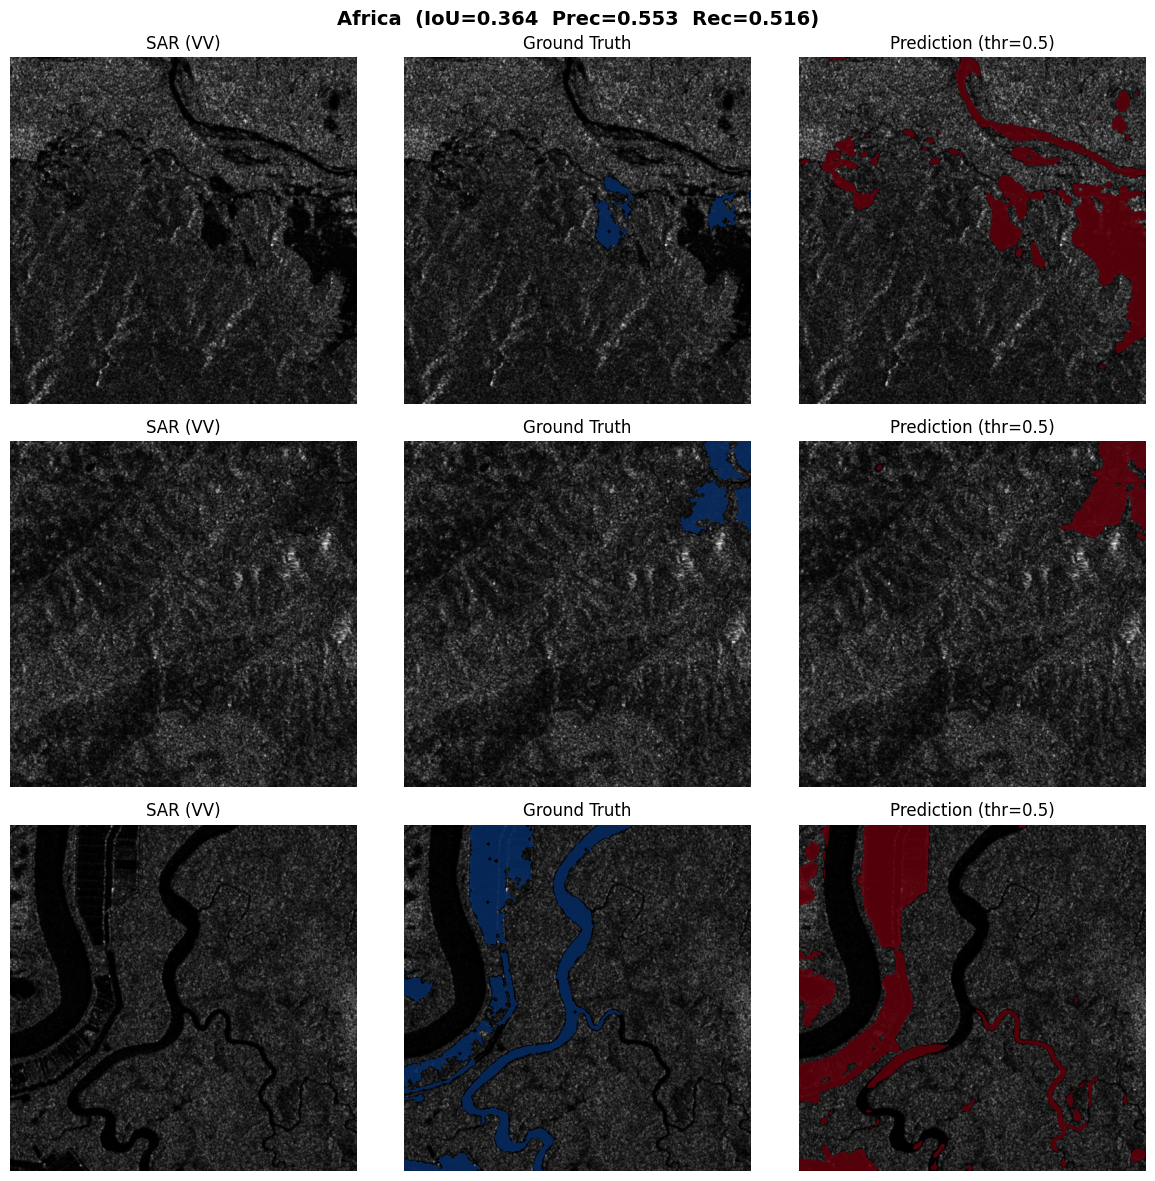

geo_vis_Africa.png


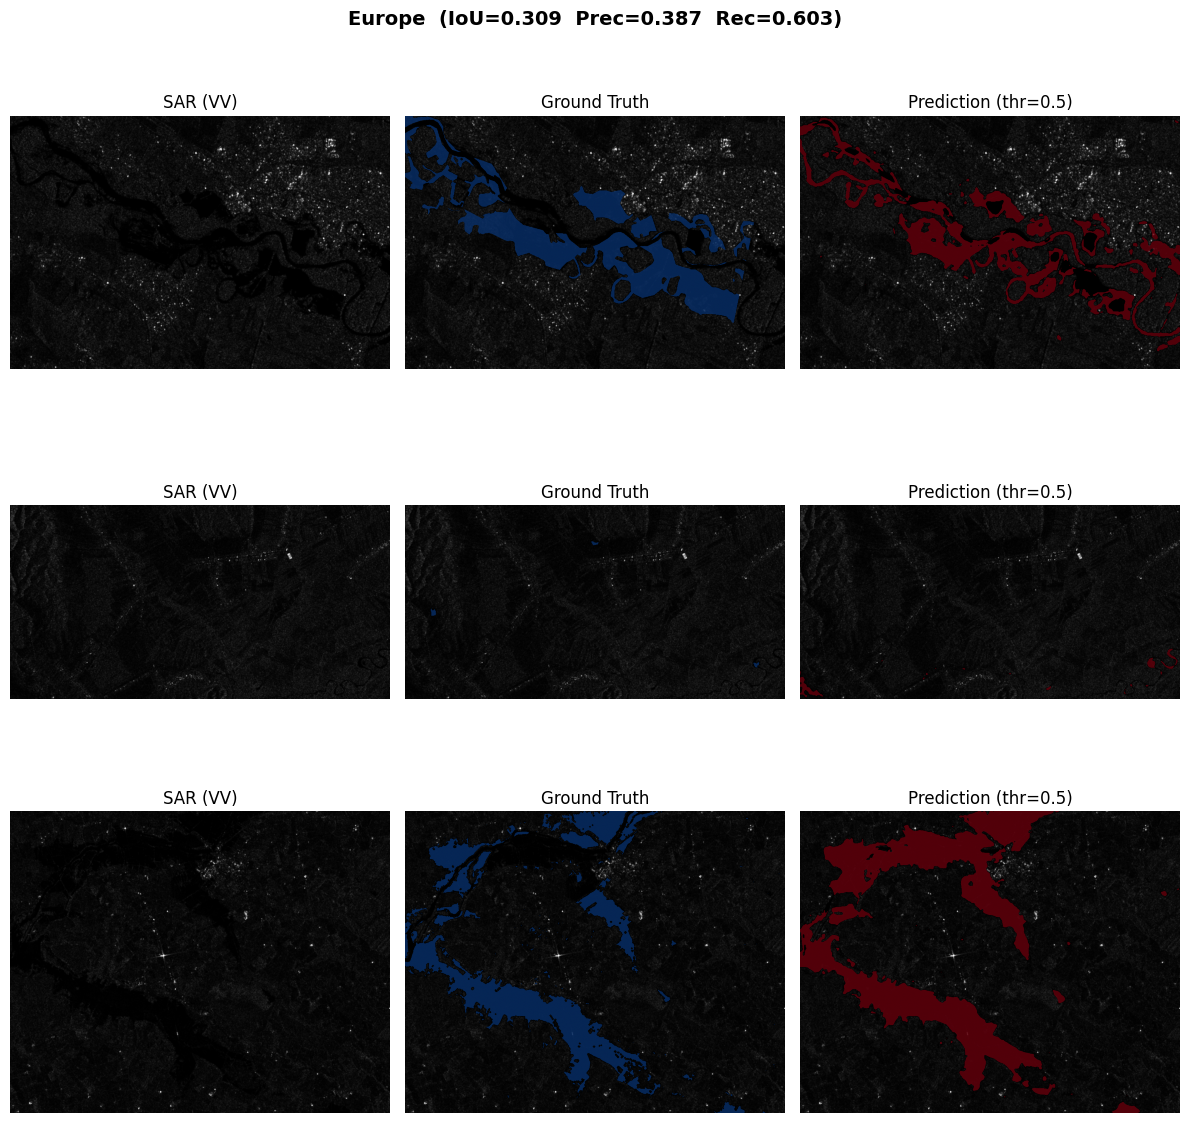

geo_vis_Europe.png


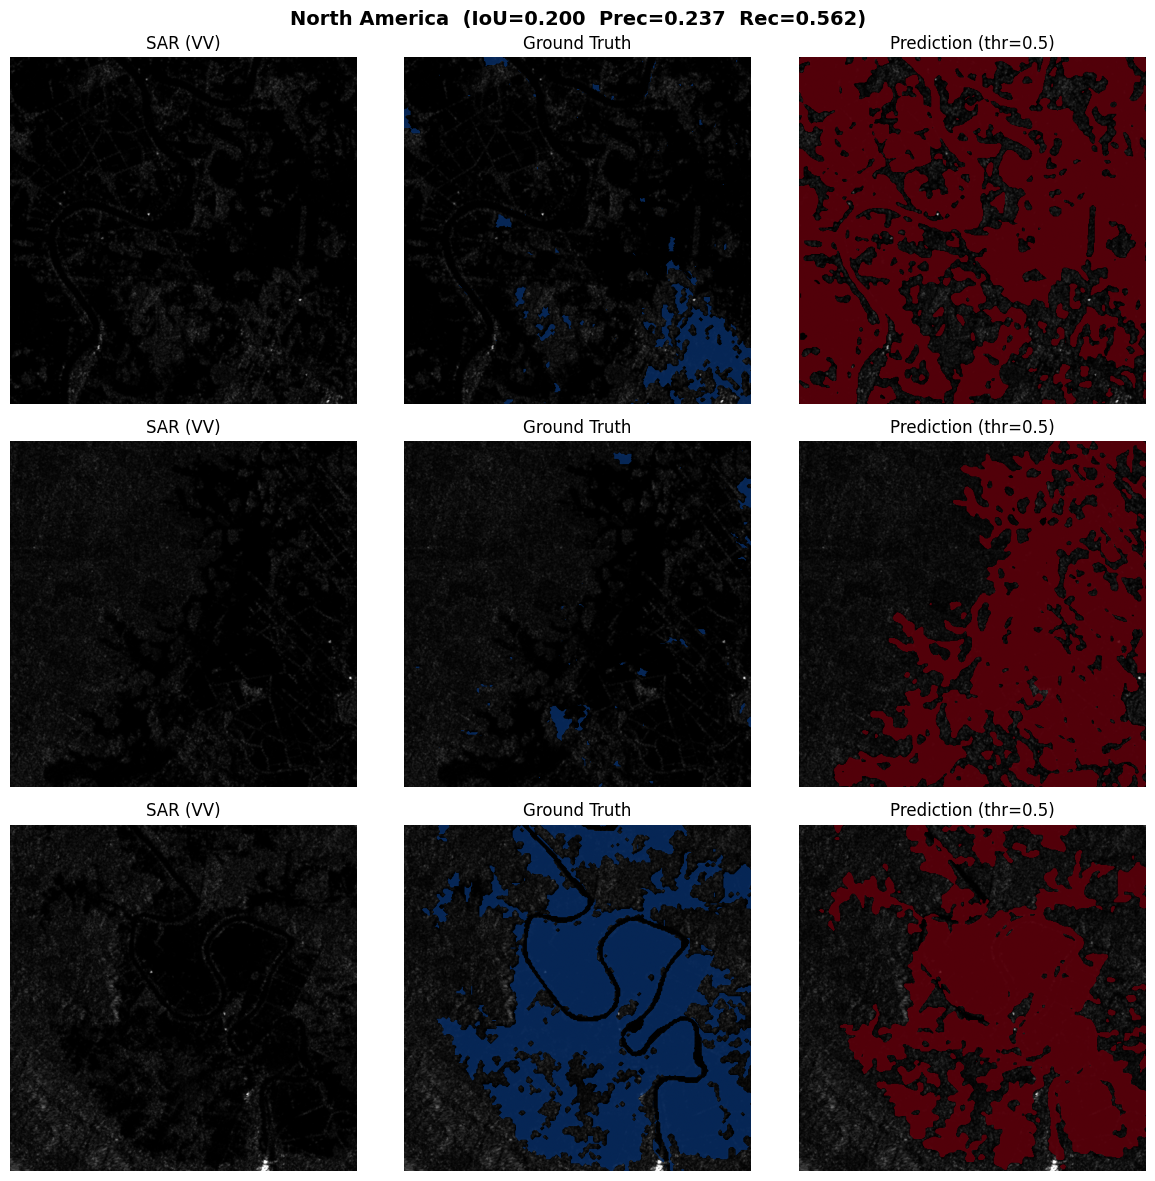

geo_vis_North_America.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_geo_samples(model, dataset, indices, n_samples=3, thr=REPORT_THR, continent_name="", seed=None):
    model.eval()
    if seed is not None:
        np.random.seed(seed)
    samples = np.random.choice(indices, min(n_samples, len(indices)), replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f'{continent_name}  (IoU={geo_results[continent_name]["iou"]:.3f}  '
                 f'Prec={geo_results[continent_name]["precision"]:.3f}  '
                 f'Rec={geo_results[continent_name]["recall"]:.3f})',
                 fontsize=14, fontweight='bold')

    for row, idx in enumerate(samples):
        x_original, y_original, *_ = dataset[idx]

#padding needs to be /32
        B, C, H, W = x_original.unsqueeze(0).shape
        pad_h = (32 - H % 32) % 32
        pad_w = (32 - W % 32) % 32

        x_padded = F.pad(x_original.unsqueeze(0), (0, pad_w, 0, pad_h), value=0)
        y_padded = F.pad(y_original.unsqueeze(0), (0, pad_w, 0, pad_h), value=255)

        with torch.no_grad():
            logits = model(x_padded.to(device))
            pred = (torch.sigmoid(logits) > thr).squeeze().cpu().numpy()

        #visualization without padding
        if pad_h > 0 or pad_w > 0:
            pred = pred[:H, :W]
        sar = x_original[0].numpy()
        sar_vis = np.clip((sar - sar.min()) / (sar.max() - sar.min() + 1e-7), 0, 1)
        pred_vis = pred.astype(float)
        pred_vis[pred_vis == 0] = np.nan
        pred_vis[y_original.numpy() == 255] = np.nan

        gt = y_original.numpy().astype(float)
        gt[gt == 0] = np.nan
        gt[gt == 255] = np.nan

        axes[row, 0].imshow(sar_vis, cmap='gray')
        axes[row, 0].set_title('SAR (VV)')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(sar_vis, cmap='gray')
        axes[row, 1].imshow(gt, cmap='Blues', alpha=0.8, vmin=0, vmax=1)
        axes[row, 1].set_title('Ground Truth')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(sar_vis, cmap='gray')
        axes[row, 2].imshow(pred_vis, cmap='Reds', alpha=0.8, vmin=0, vmax=1)
        axes[row, 2].set_title(f'Prediction (thr={thr})')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/geo_vis_{continent_name.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'geo_vis_{continent_name.replace(" ", "_")}.png')

for continent in ['Africa', 'Europe', 'North America']:
    if continent in geo_results and continent in continent_indices:
        visualize_geo_samples(
            best_model, dm.test_ds,
            continent_indices[continent],
            continent_name=continent,
            n_samples=3,
            seed=40
        )
